In [129]:
import sys
from PIL import Image
import numpy as np
import skimage.io as io
import skimage.color as color
from skimage import transform
import matplotlib.pyplot as plt
import cv2
import random

In [130]:
def create_pyramid(img, p_h, img_name):
    rows, cols, channels = img.shape
    # Create tuple of downscaled images
    pyramid = tuple(transform.pyramid_gaussian(img, downscale=p_h, channel_axis=-1))

    comp_row = max(rows, sum(p.shape[0] for p in pyramid[1:]))
    comp_cols = cols + pyramid[1].shape[1]
    comp_img = np.zeros((comp_row, comp_cols, channels), dtype=np.double)
    
    # Place the largest (original) image first
    comp_img[:rows, :cols, :] = pyramid[0]
    
    # Add in the other images
    i_row = 0
    for p in pyramid[1:]:
        n_rows, n_cols = p.shape[:2]
        comp_img[i_row:i_row + n_rows, cols:cols + n_cols, :] = p
        i_row += n_rows
   #     io.imsave(f"puppy_{i_row}x",p)

    io.imshow(comp_img)

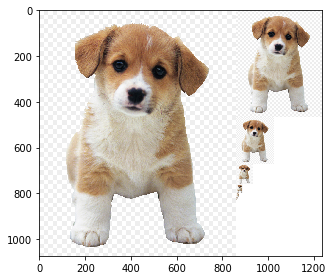

In [131]:
img = io.imread("puppy.png")
create_pyramid(img, 2.3, "puppy.png")